# Importing libraries

In [1]:
import os
import pandas as pd
import numpy as np

# Data Loading

In [2]:
DATA_FOLDER = 'KukaVelocityDataset'
col_names = np.load(os.path.join(DATA_FOLDER, 'KukaColumnNames.npy'), allow_pickle=True)
kuka_normal = np.load(os.path.join(DATA_FOLDER, 'KukaNormal.npy'), allow_pickle=True)
kuka_slow = np.load(os.path.join(DATA_FOLDER, 'KukaSlow.npy'), allow_pickle=True)

# Checking Data Types

In [3]:
print("Type:", type(kuka_normal))
print("Shape:", kuka_normal.shape)
print("Type:", type(kuka_slow))
print("Shape:", kuka_slow.shape)


Type: <class 'numpy.ndarray'>
Shape: (233792, 86)
Type: <class 'numpy.ndarray'>
Shape: (41538, 87)


In [4]:
col_names

array(['action', 'machine_nameKuka Robot_apparent_power',
       'machine_nameKuka Robot_current',
       'machine_nameKuka Robot_frequency',
       'machine_nameKuka Robot_phase_angle',
       'machine_nameKuka Robot_power',
       'machine_nameKuka Robot_power_factor',
       'machine_nameKuka Robot_reactive_power',
       'machine_nameKuka Robot_voltage', 'sensor_id1_AccX',
       'sensor_id1_AccY', 'sensor_id1_AccZ', 'sensor_id1_GyroX',
       'sensor_id1_GyroY', 'sensor_id1_GyroZ', 'sensor_id1_q1',
       'sensor_id1_q2', 'sensor_id1_q3', 'sensor_id1_q4',
       'sensor_id1_temp', 'sensor_id2_AccX', 'sensor_id2_AccY',
       'sensor_id2_AccZ', 'sensor_id2_GyroX', 'sensor_id2_GyroY',
       'sensor_id2_GyroZ', 'sensor_id2_q1', 'sensor_id2_q2',
       'sensor_id2_q3', 'sensor_id2_q4', 'sensor_id2_temp',
       'sensor_id3_AccX', 'sensor_id3_AccY', 'sensor_id3_AccZ',
       'sensor_id3_GyroX', 'sensor_id3_GyroY', 'sensor_id3_GyroZ',
       'sensor_id3_q1', 'sensor_id3_q2', 'sensor_id

In [5]:
kuka_normal

array([[  0.        , 163.162201  ,   0.976771  , ...,  -0.87426129,
          0.45091561, 180.24      ],
       [  0.        , 163.162201  ,   0.976771  , ...,  -0.87426129,
          0.45091561, 180.24      ],
       [  0.        , 163.162201  ,   0.976771  , ...,  -0.87426129,
          0.45091561, 180.24      ],
       ...,
       [  0.        , 160.462463  ,   0.993556  , ...,   0.25176759,
          0.951037  , 180.24      ],
       [  0.        , 160.462463  ,   0.993556  , ...,   0.2516482 ,
          0.95102391, 180.24      ],
       [  0.        , 160.462463  ,   0.993556  , ...,   0.2515836 ,
          0.95103188, 180.24      ]])

In [6]:
kuka_slow

array([[ 10.        , 216.610596  ,   1.201105  , ...,   0.91754389,
        180.24      ,   1.        ],
       [ 10.        , 216.610596  ,   1.201105  , ...,   0.92433231,
        180.24      ,   1.        ],
       [ 10.        , 216.610596  ,   1.201105  , ...,   0.92528504,
        180.24      ,   1.        ],
       ...,
       [  0.        , 216.71846   ,   1.265179  , ...,   0.86994425,
        180.24      ,   1.        ],
       [  0.        , 216.71846   ,   1.265179  , ...,   0.85265352,
        180.24      ,   1.        ],
       [  0.        , 216.71846   ,   1.265179  , ...,   0.8342871 ,
        180.24      ,   1.        ]])

what is that last column??
My guess is that it should be the "anomaly" column (initially)

# Converting data to pandas DataFrames for easier exploration

In [7]:
df_kuka_normal = pd.DataFrame(kuka_normal, columns=col_names[:-1])
df_kuka_slow = pd.DataFrame(kuka_slow, columns=col_names)

In [8]:
# Just to make sure that the anomaly column is the only column with missing names
print(set(df_kuka_normal.columns) - set(df_kuka_slow.columns))
print(set(df_kuka_slow.columns) - set(df_kuka_normal.columns))

set()
{'anomaly'}


In [9]:
df_kuka_normal

,action,machine_nameKuka Robot_apparent_power,machine_nameKuka Robot_current,machine_nameKuka Robot_frequency,machine_nameKuka Robot_phase_angle,machine_nameKuka Robot_power,machine_nameKuka Robot_power_factor,machine_nameKuka Robot_reactive_power,machine_nameKuka Robot_voltage,sensor_id1_AccX,...,sensor_id7_AccY,sensor_id7_AccZ,sensor_id7_GyroX,sensor_id7_GyroY,sensor_id7_GyroZ,sensor_id7_q1,sensor_id7_q2,sensor_id7_q3,sensor_id7_q4,sensor_id7_temp
0,0.0,163.162201,0.976771,50.0,320.709290,126.283424,0.773975,-103.307549,228.322586,-0.689941,...,-0.003906,1.000977,0.000000,0.000000,0.0,-0.083733,0.159157,-0.874261,0.450916,180.24
1,0.0,163.162201,0.976771,50.0,320.709290,126.283424,0.773975,-103.307549,228.322586,-0.689453,...,-0.007812,1.001465,0.000000,0.000000,0.0,-0.083733,0.159157,-0.874261,0.450916,180.24
2,0.0,163.162201,0.976771,50.0,320.709290,126.283424,0.773975,-103.307549,228.322586,-0.688965,...,-0.003418,1.000488,0.000000,0.000000,0.0,-0.083733,0.159157,-0.874261,0.450916,180.24
3,0.0,163.162201,0.976771,50.0,320.709290,126.283424,0.773975,-103.307549,228.322586,-0.689941,...,-0.004883,1.001465,0.000000,0.000000,0.0,-0.083733,0.159157,-0.874261,0.450916,180.24
4,0.0,163.162201,0.976771,50.0,320.709290,126.283424,0.773975,-103.307549,228.322586,-0.687500,...,-0.005859,0.999023,0.000000,0.000000,0.0,-0.083733,0.159157,-0.874261,0.450916,180.24
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
233787,0.0,160.462463,0.993556,50.0,321.580872,125.725021,0.783517,-99.697563,231.036530,-0.754395,...,-0.002441,1.000488,0.000000,0.000000,0.0,-0.172724,-0.048044,0.251768,0.951037,180.24
233788,0.0,160.462463,0.993556,50.0,321.580872,125.725021,0.783517,-99.697563,231.036530,-0.750977,...,-0.002930,1.000977,0.000000,0.000000,0.0,-0.172724,-0.048044,0.251768,0.951037,180.24
233789,0.0,160.462463,0.993556,50.0,321.580872,125.725021,0.783517,-99.697563,231.036530,-0.754395,...,-0.003418,0.999512,0.000000,0.000000,0.0,-0.172724,-0.048044,0.251768,0.951037,180.24
233790,0.0,160.462463,0.993556,50.0,321.580872,125.725021,0.783517,-99.697563,231.036530,-0.762695,...,-0.004883,1.000000,0.000000,0.061035,0.0,-0.172932,-0.048179,0.251648,0.951024,180.24


In [10]:
df_kuka_slow

,action,machine_nameKuka Robot_apparent_power,machine_nameKuka Robot_current,machine_nameKuka Robot_frequency,machine_nameKuka Robot_phase_angle,machine_nameKuka Robot_power,machine_nameKuka Robot_power_factor,machine_nameKuka Robot_reactive_power,machine_nameKuka Robot_voltage,sensor_id1_AccX,...,sensor_id7_AccZ,sensor_id7_GyroX,sensor_id7_GyroY,sensor_id7_GyroZ,sensor_id7_q1,sensor_id7_q2,sensor_id7_q3,sensor_id7_q4,sensor_id7_temp,anomaly
0,10.0,216.610596,1.201105,50.000000,330.759125,189.012650,0.872592,-105.793724,228.445389,-0.629883,...,1.022461,-0.976562,-9.033203,40.222168,-0.210682,0.013827,-0.336950,0.917544,180.24,1.0
1,10.0,216.610596,1.201105,50.000000,330.759125,189.012650,0.872592,-105.793724,228.445389,-0.629883,...,1.012695,-0.183105,-2.075195,6.713867,-0.211322,0.010658,-0.317552,0.924332,180.24,1.0
2,10.0,216.610596,1.201105,49.951218,330.759125,189.012650,0.872592,-105.793724,228.445389,-0.490234,...,1.019531,0.000000,-0.183105,-0.122070,-0.208518,0.014488,-0.316478,0.925285,180.24,1.0
3,10.0,216.610596,1.201105,49.951218,330.759125,189.012650,0.872592,-105.793724,228.445389,-0.623535,...,0.989258,0.061035,0.183105,-0.305176,-0.206040,0.017369,-0.316144,0.925904,180.24,1.0
4,10.0,216.610596,1.201105,49.951218,330.759125,189.012650,0.872592,-105.793724,228.445389,-0.591797,...,0.987793,-0.122070,0.122070,0.671387,-0.203967,0.019725,-0.315832,0.926423,180.24,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
41533,0.0,216.718460,1.265179,49.951218,329.322937,186.394455,0.860077,-110.552055,228.759598,-0.598633,...,1.011719,0.000000,-9.826660,42.175293,-0.156446,-0.108547,0.391621,0.900209,180.24,1.0
41534,0.0,216.718460,1.265179,49.951218,329.322937,186.394455,0.860077,-110.552055,228.759598,-0.598633,...,0.991211,-0.122070,-9.704590,41.137695,-0.152054,-0.120020,0.422892,0.885233,180.24,1.0
41535,0.0,216.718460,1.265179,49.951218,329.322937,186.394455,0.860077,-110.552055,228.759598,-0.598633,...,1.013672,0.000000,-9.643555,41.992188,-0.147580,-0.130558,0.452075,0.869944,180.24,1.0
41536,0.0,216.718460,1.265179,49.951218,329.322937,186.394455,0.860077,-110.552055,228.759598,-0.598633,...,0.997559,-0.488281,-9.948730,40.527344,-0.142647,-0.141307,0.482355,0.852654,180.24,1.0


In [11]:
df_kuka_slow["anomaly"].value_counts()

anomaly
1.0    41538
Name: count, dtype: int64

# Robot features visualization

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns

def plot_robot_power_distributions(
    df_normal,
    df_slow,
    bins=50,
    max_features_per_row=3
):
    """
    Plot comparative distributions for Robot electrical/power features.
    Assumes quasi-stationary behavior within each operating regime.
    """

    # Select robot power features
    power_cols = [
        col for col in df_normal.columns
        if col.startswith("machine_nameKuka Robot_")
    ]

    n_features = len(power_cols)
    n_cols = max_features_per_row
    n_rows = (n_features + n_cols - 1) // n_cols

    plt.figure(figsize=(5 * n_cols, 4 * n_rows))

    for i, col in enumerate(power_cols, 1):
        plt.subplot(n_rows, n_cols, i)

        sns.histplot(
            df_normal[col],
            bins=bins,
            stat="density",
            kde=True,
            color="tab:blue",
            alpha=0.5,
            label="Normal"
        )

        sns.histplot(
            df_slow[col],
            bins=bins,
            stat="density",
            kde=True,
            color="tab:orange",
            alpha=0.5,
            label="Slow"
        )

        plt.title(col.replace("machine_nameKuka Robot_", ""))
        plt.xlabel("Value")
        plt.ylabel("Density")
        plt.legend()
        plt.grid(True)

    plt.suptitle(
        "Comparative Distributions of Robot Power Features\n(Normal vs Slow)",
        fontsize=16
    )
    plt.tight_layout()
    plt.show()

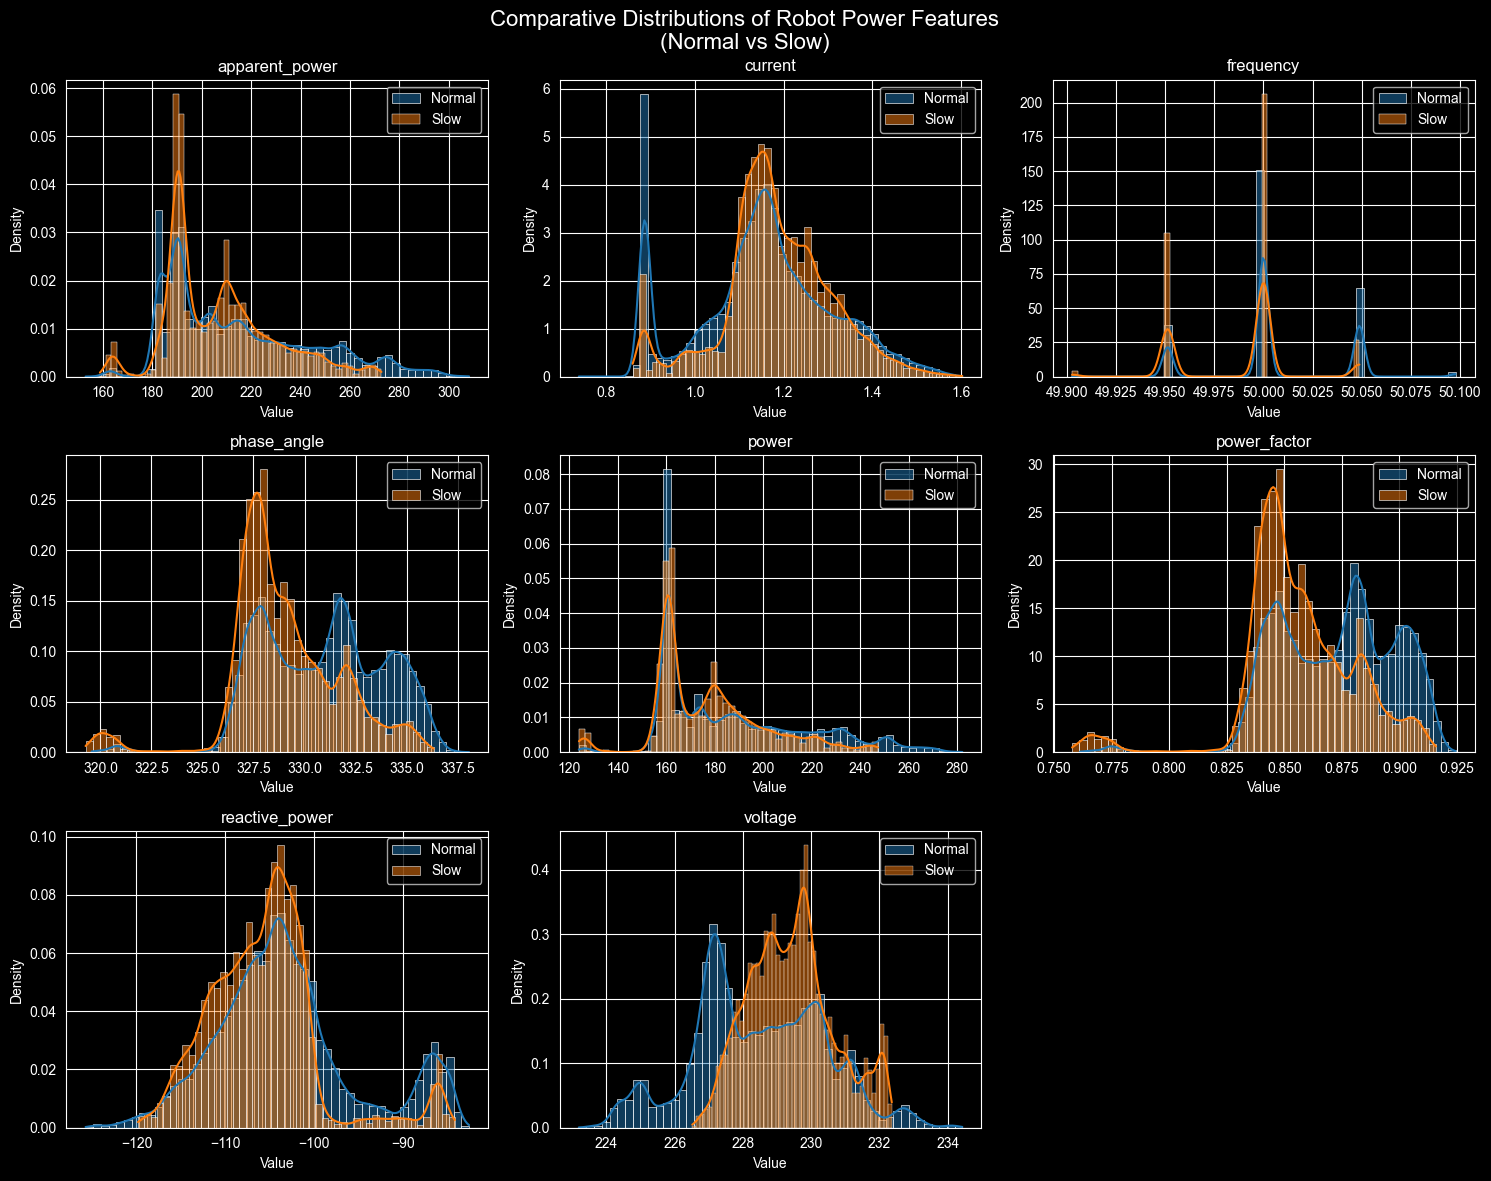

In [13]:
plot_robot_power_distributions(df_kuka_normal, df_kuka_slow)

# IMU features visualization

In [14]:
def get_imu_columns(sensor_id, imu_type):
    """
    imu_type: 'acc', 'gyro', 'quat', 'temp'
    """
    if imu_type == "acc":
        return [
            f"sensor_id{sensor_id}_AccX",
            f"sensor_id{sensor_id}_AccY",
            f"sensor_id{sensor_id}_AccZ",
        ]
    elif imu_type == "gyro":
        return [
            f"sensor_id{sensor_id}_GyroX",
            f"sensor_id{sensor_id}_GyroY",
            f"sensor_id{sensor_id}_GyroZ",
        ]
    elif imu_type == "quat":
        return [
            f"sensor_id{sensor_id}_q1",
            f"sensor_id{sensor_id}_q2",
            f"sensor_id{sensor_id}_q3",
            f"sensor_id{sensor_id}_q4",
        ]
    elif imu_type == "temp":
        return [f"sensor_id{sensor_id}_temp"]
    else:
        raise ValueError("Unknown IMU type")

In [15]:
import matplotlib.pyplot as plt
import numpy as np

def plot_imu_multiaxis_timeseries(
    df_normal,
    df_slow,
    columns,
    title,
    sample_len=200
):
    """
    Multi-axis time-series comparison for IMU signals.
    """

    t_n = np.arange(min(sample_len, len(df_normal)))
    t_s = np.arange(min(sample_len, len(df_slow)))

    fig, axes = plt.subplots(1, 2, figsize=(14, 4), sharey=True)

    # Normal
    for col in columns:
        axes[0].plot(t_n, df_normal[col].iloc[:sample_len], label=col)
    axes[0].set_title("Normal Operation")
    axes[0].set_xlabel("Time step")
    axes[0].set_ylabel("Signal value")
    axes[0].grid(True)
    axes[0].legend()

    # Slow
    for col in columns:
        axes[1].plot(t_s, df_slow[col].iloc[:sample_len], label=col)
    axes[1].set_title("Slow Operation")
    axes[1].set_xlabel("Time step")
    axes[1].grid(True)
    axes[1].legend()

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


def plot_imu_temperature(
    df_normal,
    df_slow,
    column,
    sample_len=1000
):
    t_n = np.arange(min(sample_len, len(df_normal)))
    t_s = np.arange(min(sample_len, len(df_slow)))

    plt.figure(figsize=(12, 4))

    plt.plot(t_n, df_normal[column].iloc[:sample_len], label="Normal")
    plt.plot(t_s, df_slow[column].iloc[:sample_len], label="Slow")

    plt.title(f"IMU Temperature – {column}")
    plt.xlabel("Time step")
    plt.ylabel("Temperature")
    plt.legend()
    plt.grid(True)
    plt.show()

def imu_eda(
    df_normal,
    df_slow,
    sensor_id,
    sample_len=200
):
    # Accelerometer
    plot_imu_multiaxis_timeseries(
        df_normal,
        df_slow,
        get_imu_columns(sensor_id, "acc"),
        title=f"Sensor {sensor_id} – Accelerometer (AccX/Y/Z)",
        sample_len=sample_len
    )

    # Gyroscope
    plot_imu_multiaxis_timeseries(
        df_normal,
        df_slow,
        get_imu_columns(sensor_id, "gyro"),
        title=f"Sensor {sensor_id} – Gyroscope (GyroX/Y/Z)",
        sample_len=sample_len
    )

    # Orientation (Quaternions)
    plot_imu_multiaxis_timeseries(
        df_normal,
        df_slow,
        get_imu_columns(sensor_id, "quat"),
        title=f"Sensor {sensor_id} – Orientation (q1–q4)",
        sample_len=sample_len
    )

    # Temperature
    plot_imu_temperature(
        df_normal,
        df_slow,
        get_imu_columns(sensor_id, "temp")[0],
        sample_len=sample_len * 5
    )


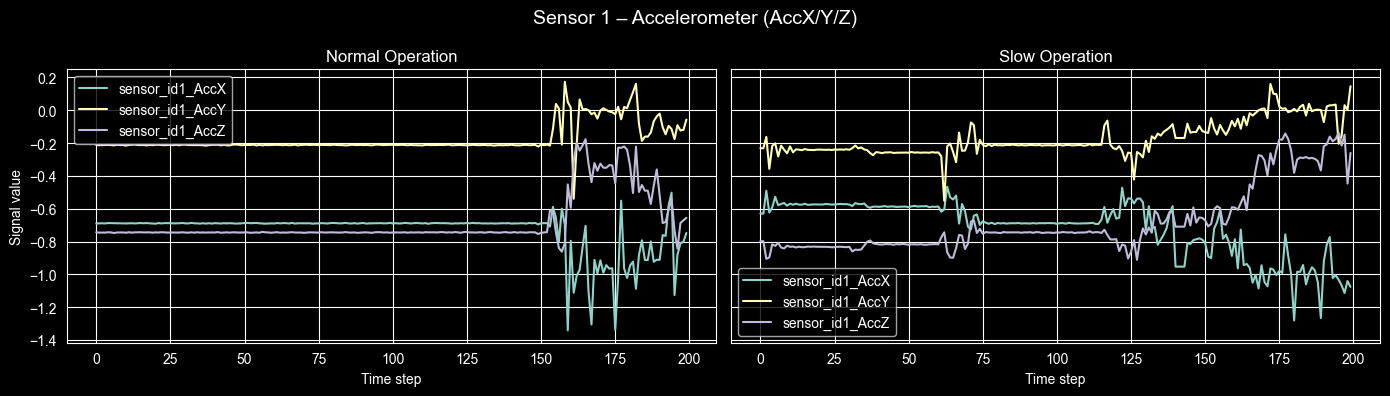

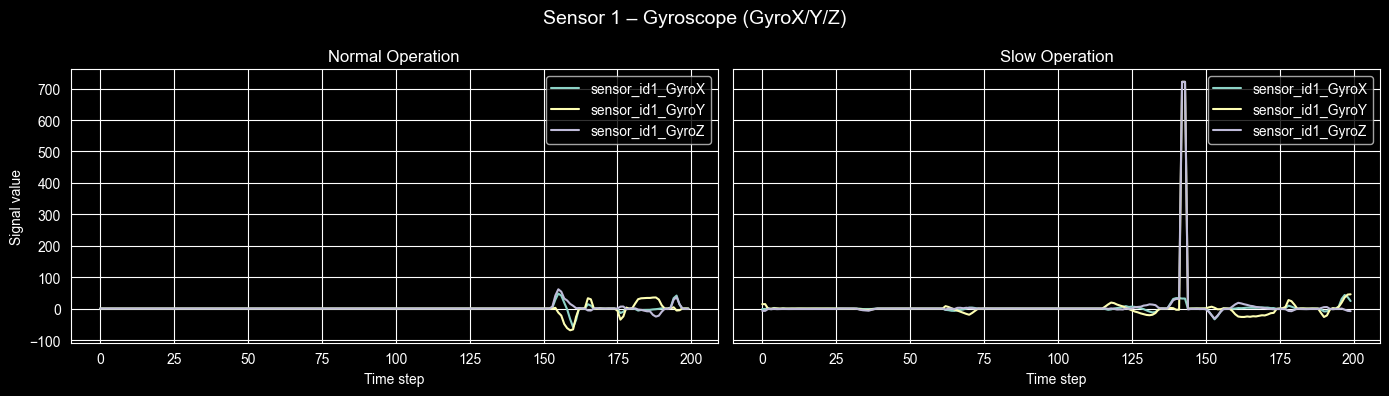

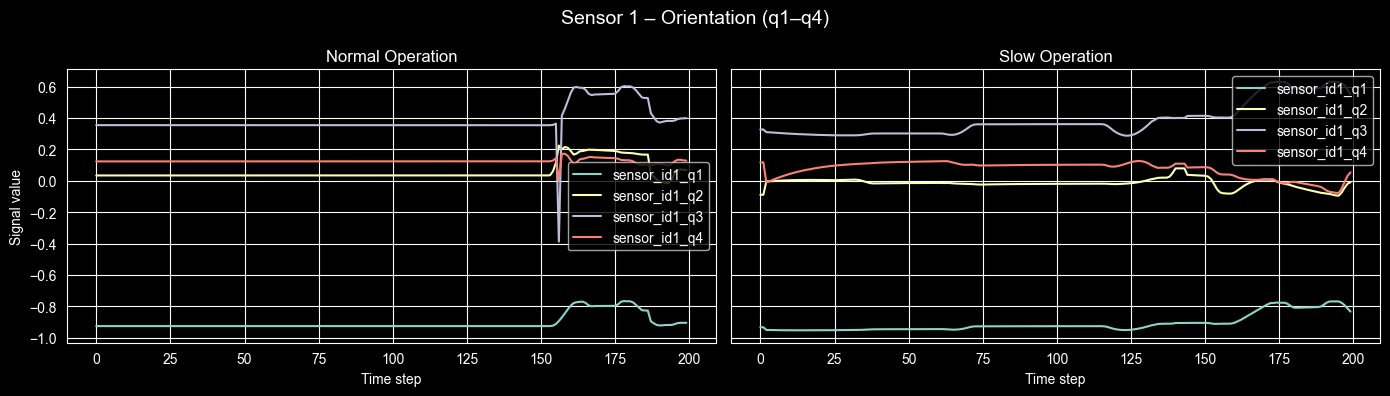

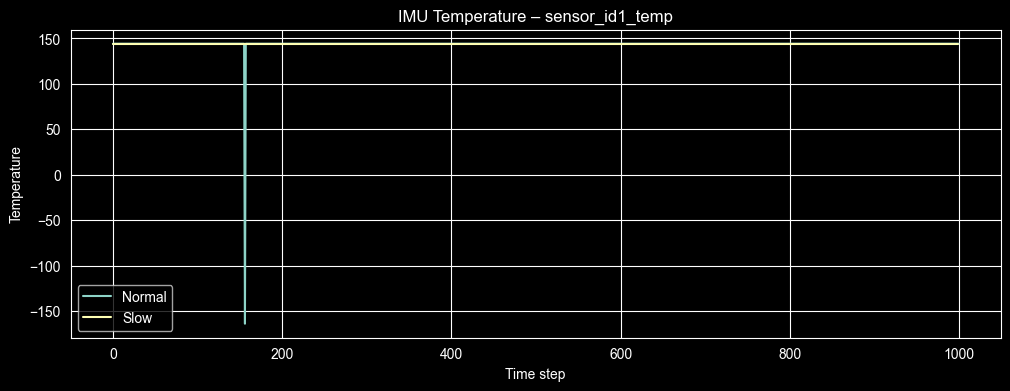

In [16]:
    # Sensor 1
imu_eda(df_kuka_normal, df_kuka_slow, sensor_id=1, sample_len=200)



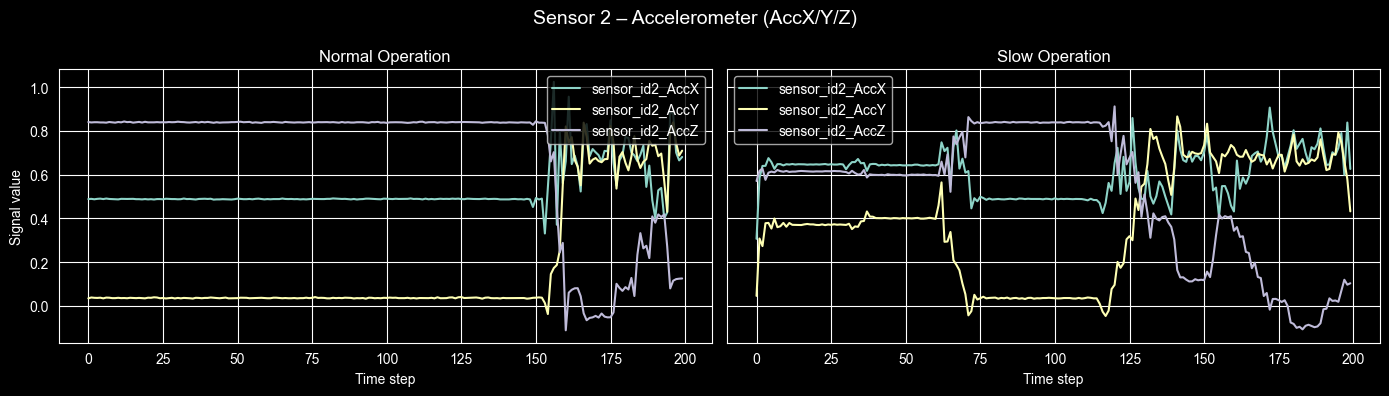

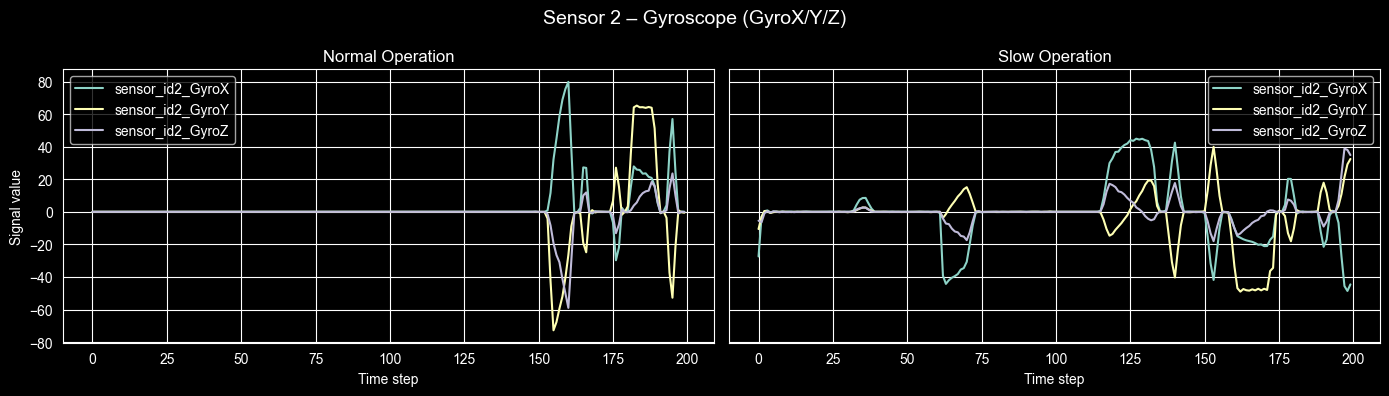

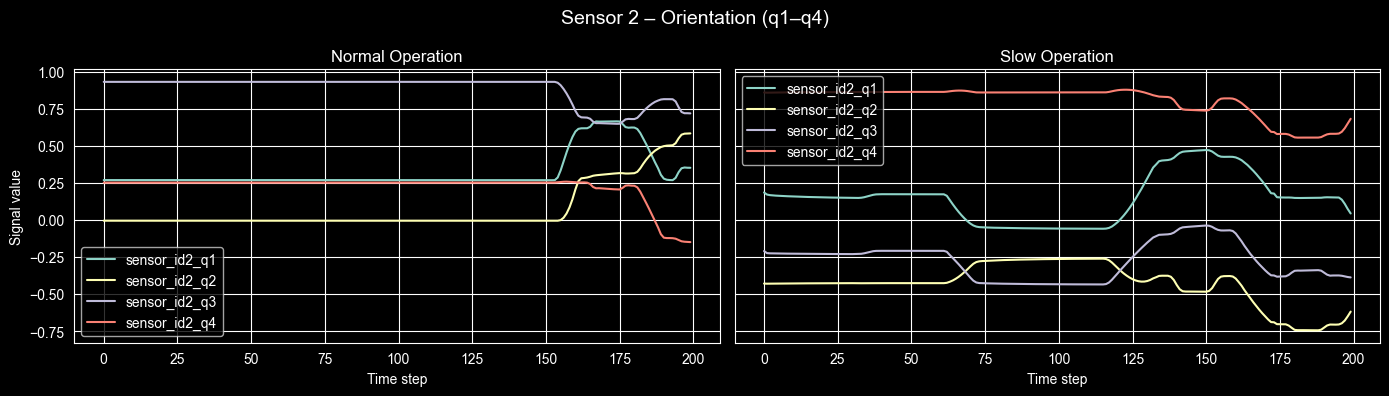

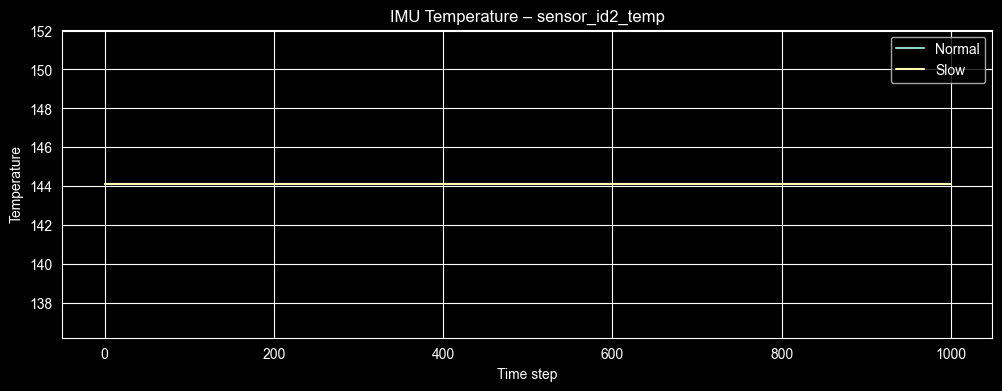

In [17]:
imu_eda(df_kuka_normal, df_kuka_slow, sensor_id=2,sample_len=200)

In [18]:
import numpy as np
import matplotlib.pyplot as plt

def plot_imu_property_across_sensors(
    df_normal,
    df_slow,
    imu_type,
    sensor_ids,
    sample_len=200
):
    """
    Property-centric IMU plots.
    Rows   -> components (X/Y/Z or q1–q4 or temp)
    Columns-> Normal vs Slow
    Lines  -> sensor IDs
    """

    if imu_type == "acc":
        components = ["X", "Y", "Z"]
        col_fmt = "sensor_id{sid}_Acc{c}"
        ylabel = "Acceleration"
    elif imu_type == "gyro":
        components = ["X", "Y", "Z"]
        col_fmt = "sensor_id{sid}_Gyro{c}"
        ylabel = "Angular velocity"
    elif imu_type == "quat":
        components = ["q1", "q2", "q3", "q4"]
        col_fmt = "sensor_id{sid}_{c}"
        ylabel = "Quaternion value"
    elif imu_type == "temp":
        components = ["temp"]
        col_fmt = "sensor_id{sid}_temp"
        ylabel = "Temperature"
    else:
        raise ValueError("imu_type must be one of {'acc','gyro','quat','temp'}")

    n_rows = len(components)
    fig, axes = plt.subplots(
        n_rows, 2, figsize=(14, 3.2 * n_rows), sharex=True
    )

    if n_rows == 1:
        axes = np.array([axes])

    t_n = np.arange(min(sample_len, len(df_normal)))
    t_s = np.arange(min(sample_len, len(df_slow)))

    for r, comp in enumerate(components):
        for sid in sensor_ids:
            col = col_fmt.format(sid=sid, c=comp)

            axes[r, 0].plot(
                t_n,
                df_normal[col].iloc[:sample_len],
                label=f"S{sid}",
                alpha=0.8
            )

            axes[r, 1].plot(
                t_s,
                df_slow[col].iloc[:sample_len],
                label=f"S{sid}",
                alpha=0.8
            )

        axes[r, 0].set_title(f"Normal – {imu_type.upper()} {comp}")
        axes[r, 1].set_title(f"Slow – {imu_type.upper()} {comp}")

        axes[r, 0].set_ylabel(ylabel)
        axes[r, 0].grid(True)
        axes[r, 1].grid(True)

        if r == 0:
            axes[r, 0].legend(
                ncol=min(len(sensor_ids), 4),
                fontsize=8,
                frameon=False
            )

    fig.suptitle(
        f"IMU {imu_type.upper()} – Property-centric View (All Sensors)",
        fontsize=14
    )
    axes[-1, 0].set_xlabel("Time step")
    axes[-1, 1].set_xlabel("Time step")

    plt.tight_layout()
    plt.show()

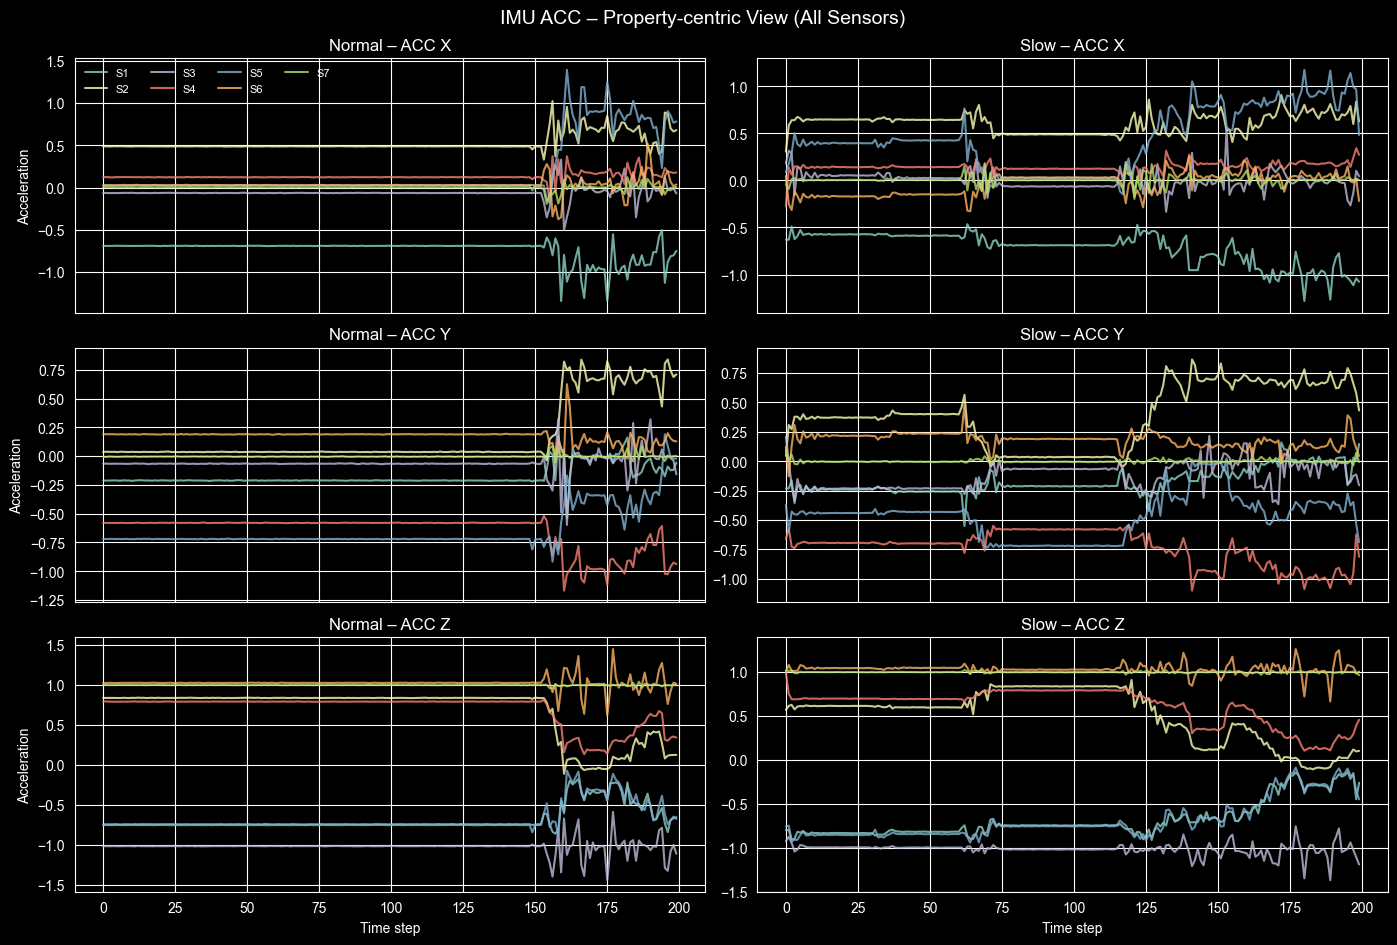

In [19]:
sensor_ids = [1, 2, 3, 4, 5, 6, 7]

# Accelerometer (all sensors together)
plot_imu_property_across_sensors(
    df_kuka_normal, df_kuka_slow,
    imu_type="acc",
    sensor_ids=sensor_ids,
    sample_len=200
)

# # Gyroscope
# plot_imu_property_across_sensors(
#     df_normal, df_slow,
#     imu_type="gyro",
#     sensor_ids=sensor_ids,
#     sample_len=200
# )
#
# # Orientation (quaternions)
# plot_imu_property_across_sensors(
#     df_normal, df_slow,
#     imu_type="quat",
#     sensor_ids=sensor_ids,
#     sample_len=200
# )
#
# # Temperature (longer horizon makes sense)
# plot_imu_property_across_sensors(
#     df_normal, df_slow,
#     imu_type="temp",
#     sensor_ids=sensor_ids,
#     sample_len=1000
# )
